# **Level 1 (Basic) — Task 2: Exploratory Data Analysis (EDA)**

**Internship:** Codveda Virtual Data Science Internship  
**Level:** 1 — Basic | **Task:** 2 of 2  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

---

## Project Overview

This notebook performs a full Exploratory Data Analysis (EDA) on the merged telecom customer churn dataset. The dataset was cleaned and feature-engineered in Level 1, Task 1. That full pipeline is reproduced here (without normalization) so the data is in its raw, readable scale — normalization is intentionally excluded because scaled values make chart axes meaningless to interpret.

**Dataset:** `churn-bigml-80.csv` (2,666 rows) + `churn-bigml-20.csv` (667 rows) → merged: **3,333 rows**  
**Post-cleaning columns:** 31 (20 original + 11 engineered features)  
**Target variable:** `Churn` — binary (0 = stayed, 1 = left)  
**Class balance:** 85.5% non-churners vs 14.5% churners — imbalanced dataset  

---

## Task Objectives

- Compute and interpret summary statistics across all features
- Plot histograms to understand feature distributions, split by churn status
- Plot box plots to compare feature ranges between churners and non-churners
- Plot scatter plots to reveal relationships between paired features
- Build a correlation matrix to quantify what drives churn
- Derive written insights: which features matter, which don't, and what a business should act on

---

## Notebook Structure

1. Environment Setup
2. Phase 1 — Loading & Merging the Dataset
3. Phase 2 — Data Sanitization
4. Phase 3 — Feature Engineering & Encoding
5. Phase 4 — Final Check
6. Phase 5 — Summary Statistics
7. Phase 6 — Distributions (Histograms)
8. Phase 7 — Box Plots
9. Phase 8 — Scatter Plots
10. Phase 9 — Correlation Matrix
11. Phase 10 — Key Insights & Findings


## 1. Environment Setup

We begin by connecting to Google Drive (where the datasets are stored) and importing the core libraries.

- **`pandas`** — data loading, manipulation, and inspection
- **`numpy`** — numerical operations and conditional column creation (`np.where`, `np.select`)


In [4]:
#Connect google drive to colab notebook
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional

num_features = ['Account length', 'Total day minutes', 'Total day charge', 'Total eve minutes', 'Total night minutes', 'Total intl minutes', 'Customer service calls', 'Number vmail messages', 'value_score']

def plot_feature_distributions(df, features):
    """
    Plots a matrix of histogram to compare dostributions of features.
    """
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()

    for i, col in enumerate(features):
        sns.histplot(
            data=df,
            x=col,
            ax=axes[i],
            hue='Churn',
            stat='density',        # ADDED: normalizes each group to area=1
            common_norm=False,     # ADDED: normalizes each group independently
            kde=True,
            alpha=0.4,
            edgecolor="white",
        )

        axes[i].set_title(f"Distribution of {col.title()}", fontsize=13, weight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Density')   # ADDED: y-axis label now reflects what's actually plotted
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

    plt.tight_layout(pad=4.0)
    plt.show()

def plot_boxplots(df, features, target='Churn'):
    """
    Plots a matrix of boxplots to compare features against Churn status.
    """
    fig, axes = plt.subplots(3, 3, figsize=(16, 20))
    axes = axes.flatten()

    # Professional Palette
    # Using a 2-color palette to distinguish 'Stayed' vs 'Left'
    palette = {1: "#D62728", 0: "#1F77B4"}

    # The Loop
    for i, col in enumerate(features):
        sns.boxplot(
            data=df,
            x=target,
            y=col,
            ax=axes[i],
            palette=palette,
            hue=target, # Avoids future warnings
            legend=False,
            width=0.6,
            fliersize=4 # Size of the outlier dots
        )

        # Styling
        axes[i].set_title(f"{col.replace('_', ' ').title()} by {target}", fontsize=14, weight='bold')
        axes[i].set_xlabel("Did the Customer Churn?", fontsize=10)
        axes[i].set_ylabel("Value", fontsize=10)
        sns.despine(ax=axes[i])

    # Clean up: Hide the 8th (empty) slot
    if len(features) < len(axes):
        axes[-1].set_axis_off()

    plt.tight_layout(pad=3.0)
    plt.show()

def plot_scatterplots(df, list1, list2, color='Churn'):
    """
    Plots a matrix of scatterplots pairing items from list1 and list2.
    """
    # Create the pairing (e.g., total_day_minutes paired with total_day_charge)
    feature_pairs = list(zip(list1, list2))

    # We have 5 pairs, so a 3x2 grid (6 slots) is perfect
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    axes = axes.flatten()

    # The Loop: iterating through the paired features
    for i, (f1, f2) in enumerate(feature_pairs):
        sns.scatterplot(
            data=df,
            x=f1,
            y=f2,
            hue=color,
            ax=axes[i],
            palette='viridis',
            alpha=0.6,
            edgecolor="white"
        )

        # Styling the titles and labels
        # Making the titles look professional by replacing underscores
        axes[i].set_title(f"{f1.replace('_', ' ').title()}\nvs {f2.replace('_', ' ').title()}",
                          fontsize=12, weight='bold')
        axes[i].set_xlabel(f1.replace('_', ' ').capitalize())
        axes[i].set_ylabel(f2.replace('_', ' ').capitalize())

        # Move the legend to a better spot or hide it to keep it clean
        if i == 0:
            axes[i].legend(title=color.title(), loc='upper right')
        else:
            axes[i].get_legend().remove()

        sns.despine(ax=axes[i])

    # Clean up: Hide any unused axes (like the 6th slot)
    for j in range(len(feature_pairs), len(axes)):
        axes[j].set_axis_off()

    plt.tight_layout(pad=4.0)
    plt.show()

sns.set_theme(style='whitegrid')

## 2. Phase 1 — Loading & Merging the Dataset

Before any cleaning, we need to understand what we're working with.
We load each file separately and inspect them individually — checking shape, column types, and a few sample rows — before combining them.
This lets us catch any structural differences between the two files early.

**Why label `data_type` before merging?**
Once two DataFrames are stacked into one, there's no way to tell which row came from which file.
Adding a `'train'`/`'test'` label *before* concatenation preserves that provenance.
This matters if you ever want to reconstruct the original split for modelling.


In [6]:
#read in the two churn datasets
churn_1 = pd.read_csv('/content/drive/MyDrive/Codveda task 1(Level1(Basic)-Data Cleaning & Preprocessing)/churn-bigml-80.csv')
churn_2 = pd.read_csv('/content/drive/MyDrive/Codveda task 1(Level1(Basic)-Data Cleaning & Preprocessing)/churn-bigml-20.csv')

In [7]:
#preview and overview of churn 1
print(churn_1.info())
churn_1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [8]:
#preview and overview of churn 2
print(churn_2.info())
churn_2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null    fl

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [9]:
#Add a column data_type to both ('train' and 'test') before merging so you can easily split them later without confusion.
churn_1['data_type'] = 'train'
churn_2['data_type'] = 'test'

In [10]:
#merge churn datasets to clean and engineer features
df = pd.concat([churn_1, churn_2], axis=0).reset_index(drop=True)

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,data_type
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,...,16.78,244.7,91,11.01,10.0,3,2.70,1,False,train
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,...,16.62,254.4,103,11.45,13.7,3,3.70,1,False,train
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,...,10.30,162.6,104,7.32,12.2,5,3.29,0,False,train
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,...,5.26,196.9,89,8.86,6.6,7,1.78,2,False,train
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,...,12.61,186.9,121,8.41,10.1,3,2.73,3,False,train


**Merge result:** 3,333 rows × 21 columns — 20 original features + the `data_type` tracking column. The index has been reset so rows are numbered 0–3332 continuously. No structural differences were found between the two files — same columns, same dtypes throughout.


## 3. Phase 2 — Data Sanitization

This phase ensures the data is trustworthy before any analytical work begins. We check three things:

1. **Missing values** — any NaN/null entries that would break calculations or distort statistics
2. **Data type correctness** — columns stored in the wrong type (e.g. phone codes stored as integers)
3. **Logical consistency** — rows that are internally inconsistent (e.g. charges recorded against zero minutes)


In [11]:
#Handle missing values
df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


> **Result:** All 21 columns return 0 missing values across all 3,333 rows. This is a clean dataset out of the box — no imputation needed.


In [12]:
#convert 'Area code' from integer to string
df['Area code'] = df['Area code'].astype(str)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   object 
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

**Why convert `Area code` to string?**
Area codes are identifiers, not quantities — 408, 415, and 510 are labels, not measurements.
Leaving them as integers risks two problems:
(1) a normalization step would scale them, which is meaningless for a categorical code, and
(2) a correlation matrix would treat them as numeric, producing spurious correlations.
Casting to `str` signals to every downstream process: *this column is a label, not a number*.


In [13]:
# Ensure "Yes/No" or State codes are consistent (no weird spaces or casing issues like "yes" vs "Yes").
df['Voice mail plan'].unique()

array(['Yes', 'No'], dtype=object)

> **Result:** `Voice mail plan` contains only `'Yes'` and `'No'` — no casing inconsistencies, no unexpected values.

### Outlier Investigation — Logical Consistency Checks

Rather than purely statistical outlier detection, we apply domain knowledge here.
In a telecom billing dataset, a *charge with zero minutes* is a billing anomaly — it means a customer was charged for calls they didn't make.
We check all four billing categories (day, evening, night, international) for this condition.


In [14]:
#Identify rows where Minutes are 0 but Charges are $>0$ (or vice versa) to decide if they are outliers.
df_day = df[(df['Total day minutes'] == 0) & (df['Total day charge'] > 0)]
df_day.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,data_type


In [15]:
df_eve = df[(df['Total eve minutes'] == 0) & (df['Total eve charge'] > 0)]
df_eve.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,data_type


In [16]:
df_night = df[(df['Total night minutes'] == 0) & (df['Total night charge'] > 0)]
df_night.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,data_type


In [17]:
df_night = df[(df['Total intl minutes'] == 0) & (df['Total intl charge'] > 0)]
df_night.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,data_type


> **Result:** All four checks return empty DataFrames. No rows have charges without corresponding minutes.
The dataset is logically consistent — no billing anomalies detected.

> **Note:** A standard duplicate rows check (`df.duplicated().sum()`) is also recommended in a complete sanitization pipeline. Worth adding for future reference.


## 4. Phase 3 — Feature Engineering & Encoding

The original 20 columns tell us *what happened* (minutes used, charges incurred) but not much about *what kind of customer this is*.
Feature engineering transforms and combines existing columns into new ones that carry richer analytical signal.

**New features created:**

| Feature | Type | What it captures |
|---|---|---|
| `day_rate`, `eve_rate`, `night_rate`, `intl_rate` | Numeric | Price per minute by billing period |
| `is_loyal` | Binary | Whether account length exceeds the loyalty threshold |
| `vmail_user_type` | Categorical | How the customer uses (or doesn't) their voicemail plan |
| `service_sentiment` | Categorical | Customer friction level based on service call frequency |
| `total_overall_charge` | Numeric | Total bill across all billing periods |
| `total_minutes` | Numeric | Total call volume across all periods |
| `value_score` | Numeric | Effective rate — total spend ÷ total minutes |

We also binary-encode `International plan`, `Voice mail plan`, and `Churn` as integers (0/1) for compatibility with correlation matrices and ML pipelines.


In [18]:
#The "Rate" Engineering (Price Sensitivity)
df['day_rate'] = df['Total day charge'] / df['Total day minutes']
df['eve_rate'] = df['Total eve charge'] / df['Total eve minutes']
df['night_rate'] = df['Total night charge'] / df['Total night minutes']
df['intl_rate'] = df['Total intl charge'] / df['Total intl minutes']

# List of the rate columns we created
rate_cols = ['day_rate', 'eve_rate', 'night_rate', 'intl_rate']

# Filling all NaN values (from 0/0 divisions) with 0
df[rate_cols] = df[rate_cols].fillna(0)

**Why create rate columns?**
Absolute totals (minutes used, charges incurred) don't tell the full story.
Rate = Charge ÷ Minutes gives the *price per minute* — a normalised cost efficiency measure.
Two customers can have the same total charge but very different per-minute rates depending on usage volume.

**The NaN fix:** When both minutes and charges are 0 (no activity in that period), the division produces NaN (0 ÷ 0 is undefined). Filling with 0 is semantically correct — a rate of 0 means no usage and no charge.


In [19]:
#The "Loyalty" Threshold we use 110 days as a loyalty cutoff. In the industry, we call this "Tenure Binning."
df['is_loyal'] = np.where(df['Account length'] > 110, 1, 0)

In [20]:
df['is_loyal'].value_counts()

,count
is_loyal,
0,1984
1,1349


> **Output:** 1,984 customers are `0` (account ≤ 110 days) vs. 1,349 classified as `1` (account > 110 days) — roughly a 60/40 split.





In [21]:
#The "Ghost User" Logic: Create vmail_user_type: Categorize into Active_User, Wasteful_Payer, or Standard based on your vmail_plan and vmail_messages logic.
conditions = [
    (df['Voice mail plan'] == 'Yes') & (df['Number vmail messages'] == 0),  # Wasteful
    (df['Voice mail plan'] == 'Yes') & (df['Number vmail messages'] > 0),   # Active
    (df['Voice mail plan'] == 'No') & (df['Number vmail messages'] == 0),   # Standard
    (df['Voice mail plan'] == 'No') & (df['Number vmail messages'] > 0)     # Anomaly
]

# Define the labels for those conditions
values = ['Wasteful_Payer', 'Active_User', 'Standard', 'Anomaly']

# Create the new column
df['vmail_user_type'] = np.select(conditions, values, default='Unknown')

In [22]:
df['vmail_user_type'].unique()

array(['Active_User', 'Standard'], dtype=object)

> **Output:** Only `'Active_User'` and `'Standard'` appear in the data.
This means: every customer *with* a voicemail plan also uses it (no `Wasteful_Payer`), and no customer *without* a plan has voicemail messages (no `Anomaly`).
This is actually a useful data insight — voicemail uptake is clean and internally consistent in this dataset.


In [23]:
#The "service sentiment":Create service_sentiment: Map customer_service_calls to Normal (0-2), Nervous (3), and High_Risk (4+).
conditions = [
    (df['Customer service calls'] <= 2),
    (df['Customer service calls'] == 3),
    (df['Customer service calls'] >= 4)
    ]

# Define the labels for those conditions
values = ['Normal', 'Nervous', 'High_Risk']

# Create the new column
df['service_sentiment'] = np.select(conditions, values, default='Unknown')

In [24]:
df['service_sentiment'].value_counts()

,count
service_sentiment,
Normal,2637
Nervous,429
High_Risk,267


> **Output:** Normal: 2,637 (79%) | Nervous: 429 (13%) | High_Risk: 267 (8%)

> The 267 High_Risk customers will be particularly interesting to examine in the EDA — high service call frequency is one of the stronger known indicators of churn in telecom datasets.


In [25]:
# Create total_overall_charge: Sum of Day + Eve + Night + Intl charges. This helps see the "Bill Shock" factor.
df['total_overall_charge'] = df['Total day charge'] + df['Total eve charge'] + df['Total night charge'] + df['Total intl charge']

# Total Minutes: Summing all usage categories (Day, Eve, Night, Intl) to capture the customer's total "Volume of Activity" across all time buckets.
df['total_minutes'] = (df['Total day minutes'] + df['Total eve minutes'] + df['Total night minutes'] + df['Total intl minutes'])

# Value Score: Calculating the "Effective Rate" (Total Spend / Total Minutes).
# This measures cost-efficiency; customers with a high score are paying more per minute and may be more sensitive to competitor pricing.
df['value_score'] = df['total_overall_charge'] / df['total_minutes'].replace(0, np.nan)
df['value_score'] = df['value_score'].fillna(0)



**Why aggregate?**
`total_overall_charge` collapses all billing periods into a single 'total bill' — the number a customer actually sees on their statement. High total bills can drive churn.

`value_score` (effective rate = total charge ÷ total minutes) normalises spend by volume. A high value_score means the customer pays more per minute — a proxy for price sensitivity.

Using `.replace(0, np.nan)` before division avoids NaN from customers with zero total minutes, then `fillna(0)` handles those edge cases cleanly.


In [26]:
# Mapping binary categories to integers
# We use .map() to ensure total control over which label becomes 1 (the positive case)
df['International plan'] = df['International plan'].str.lower().map({'yes': 1, 'no': 0})
df['Voice mail plan'] = df['Voice mail plan'].str.lower().map({'yes': 1, 'no': 0})
df['Churn'] = df['Churn'].map({True: 1, False: 0})


In [27]:
# Convert mapped columns to integers so they show up in the correlation matrix
df['International plan'] = df['International plan'].astype(int)
df['Voice mail plan'] = df['Voice mail plan'].astype(int)
df['Churn'] = df['Churn'].astype(int)

**Why encode as integers?**
`.map()` with an explicit dictionary is the most transparent binary encoding method — you control exactly which label becomes 1.
The `.astype(int)` step is necessary because `.map()` can return `float64` in some cases, and integer dtype is required for clean correlation matrices and ML model inputs.




In [28]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,day_rate,eve_rate,night_rate,intl_rate,is_loyal,vmail_user_type,service_sentiment,total_overall_charge,total_minutes,value_score
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,...,0.170011,0.085005,0.044994,0.270000,1,Active_User,Normal,75.56,717.2,0.105354
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,...,0.169988,0.085013,0.045008,0.270073,0,Active_User,Normal,59.24,625.2,0.094754
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,...,0.170008,0.084983,0.045018,0.269672,1,Standard,Normal,62.29,539.4,0.115480
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,...,0.170007,0.084976,0.044997,0.269697,0,Standard,Normal,66.80,564.8,0.118272
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,...,0.170006,0.085030,0.044997,0.270297,0,Standard,Nervous,52.09,512.0,0.101738


## 5. phase 4 - Final check

The cells below verify the final state of the dataset after all transformations have been applied.


In [29]:
#final checks
print(f'The Shape of the cleaned dataset is {df.shape}')
print()
print(f'Missing values are: ')
print(df.isnull().sum())
print()
df.info()

The Shape of the cleaned dataset is (3333, 31)

Missing values are: 
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
data_type                 0
day_rate                  0
eve_rate                  0
night_rate                0
intl_rate                 0
is_loyal                  0
vmail_user_type           0
service_sentiment         0
total_overall_charge      0
total_minutes             0
value_score               0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex:

# 6. Phase 5 - Summary Statistics

Before plotting anything, we establish the baseline facts: how many customers churned, how the categorical features break down, and critically — whether any subgroup has a dramatically different churn rate. These cross-tabulations are the backbone of every insight that follows in the visualizations.


In [30]:
# Check min/max for anything suspicious for numerical columns
df.describe()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,...,Customer service calls,Churn,day_rate,eve_rate,night_rate,intl_rate,is_loyal,total_overall_charge,total_minutes,value_score
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,...,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,0.096910,0.276628,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,...,1.562856,0.144914,0.169901,0.084976,0.045000,0.268598,0.404740,59.449754,591.864776,0.100354
std,39.822106,0.295879,0.447398,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,...,1.315491,0.352067,0.004164,0.001472,0.000017,0.019798,0.490915,10.502261,89.954251,0.008440
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.044828,0.000000,0.000000,22.930000,284.300000,0.066950
25%,74.000000,0.000000,0.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,...,1.000000,0.000000,0.169989,0.084988,0.044988,0.269811,0.000000,52.380000,531.500000,0.094893
50%,101.000000,0.000000,0.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,...,1.000000,0.000000,0.170004,0.085000,0.045000,0.270000,0.000000,59.470000,593.600000,0.100385
75%,127.000000,0.000000,1.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,...,2.000000,0.000000,0.170017,0.085013,0.045013,0.270297,1.000000,66.480000,652.400000,0.106056
max,243.000000,1.000000,1.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,...,9.000000,1.000000,0.170513,0.085075,0.045111,0.272727,1.000000,96.150000,885.000000,0.129791


In [31]:
# categorical columns State, Area code, vmail_user_type, service_sentiment
df.describe(include='object')

,State,Area code,data_type,vmail_user_type,service_sentiment
count,3333,3333,3333,3333,3333
unique,51,3,2,2,3
top,WV,415,train,Standard,Normal
freq,106,1655,2666,2411,2637


In [32]:
#check if the dataset imbalanced
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.855086
1,0.144914


In [33]:
df['International plan'].value_counts(normalize=True)

,proportion
International plan,
0,0.90309
1,0.09691


In [34]:
df['Voice mail plan'].value_counts(normalize=True)

,proportion
Voice mail plan,
0,0.723372
1,0.276628


In [35]:
# churn rate by International plan, Voice mail plan, Service_sentiment
pd.crosstab(df['International plan'], df['Churn'], normalize='index')

Churn,0,1
International plan,,
0,0.885050,0.114950
1,0.575851,0.424149


In [36]:
pd.crosstab(df['Voice mail plan'], df['Churn'], normalize='index')

Churn,0,1
Voice mail plan,,
0,0.832849,0.167151
1,0.913232,0.086768


In [37]:
pd.crosstab(df['service_sentiment'], df['Churn'], normalize='index')

Churn,0,1
service_sentiment,,
High_Risk,0.483146,0.516854
Nervous,0.897436,0.102564
Normal,0.885855,0.114145


In [38]:

df.groupby(['International plan', 'Voice mail plan', 'service_sentiment'])['Churn'].mean()


International plan  Voice mail plan  service_sentiment
0                   0                High_Risk            0.536723
                                     Nervous              0.089404
                                     Normal               0.105820
                    1                High_Risk            0.387097
                                     Nervous              0.022472
                                     Normal               0.026510
1                   0                High_Risk            0.722222
                                     Nervous              0.344828
                                     Normal               0.423913
                    1                High_Risk            0.600000
                                     Nervous              0.555556
                                     Normal               0.342466
Name: Churn, dtype: float64

# 7. Phase 6 - Distributions(Histogram)

We plot density histograms (not counts) for 9 key features, split by Churn status. **Why density and not count?** The dataset is imbalanced — 85.5% non-churners vs 14.5% churners. Raw counts would bury the churner distribution entirely. Density normalizes each group to area=1, so both curves are plotted on the same scale regardless of group size. `common_norm=False` ensures each group is normalized independently.


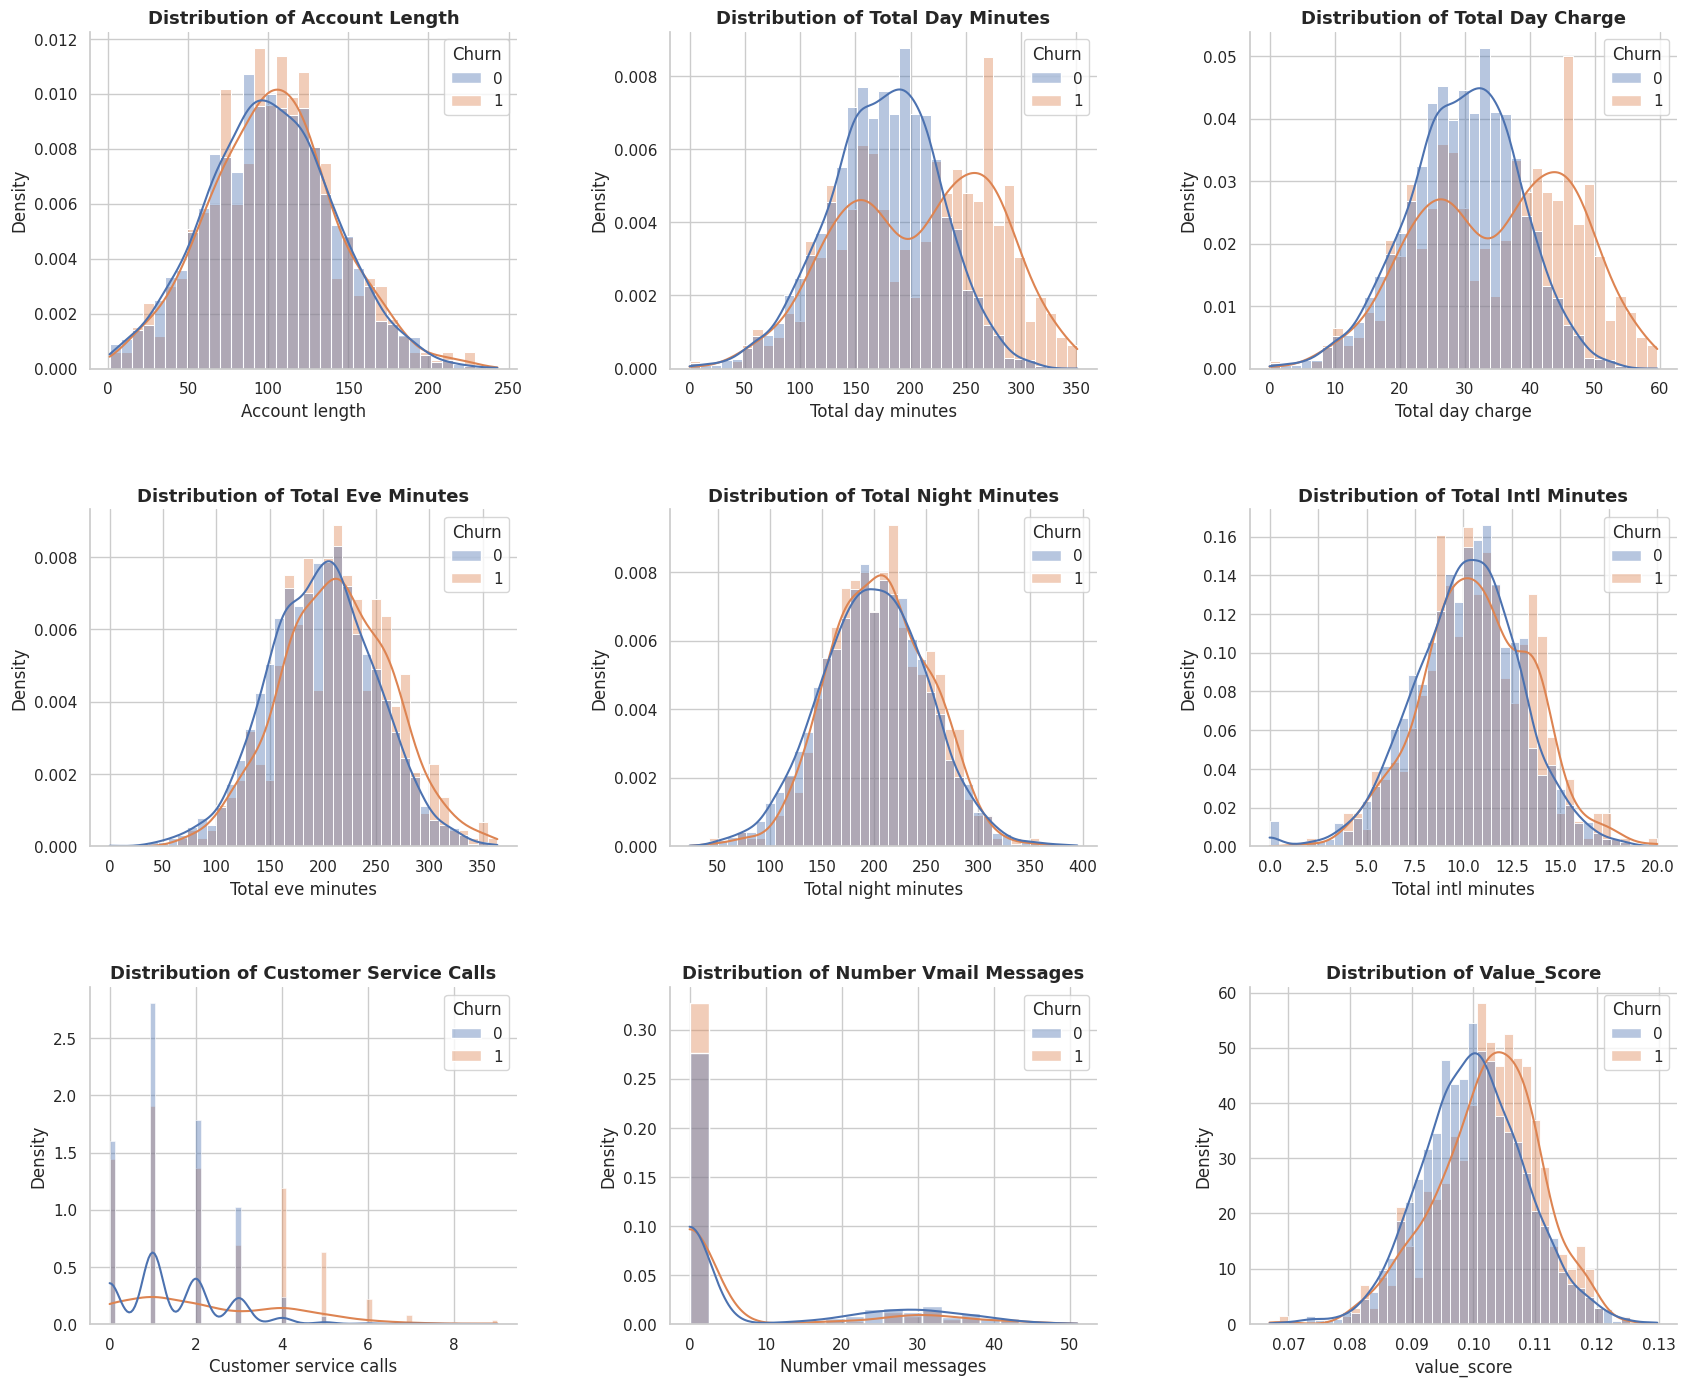

In [41]:
plot_feature_distributions(df, num_features)

# 8. Phase 7 - Box Plot - Churn vs. No Churn

Box plots show the median, spread (IQR), and outliers for each feature, split by whether the customer churned. They are better than histograms for directly comparing the two groups — if the boxes don't overlap much, that feature is a strong separator.

> **Voicemail messages — outlier note:** The box plot for `Number vmail messages` shows outliers in the Churn=1 group — customers who churned but had active voicemail messages. This is not a data error. The likely explanation is that voicemail messages accumulate passively; a customer can decide to leave without immediately cancelling their plan. The messages represent historical usage, not current intent. These data points are genuine observations, not noise to be removed.


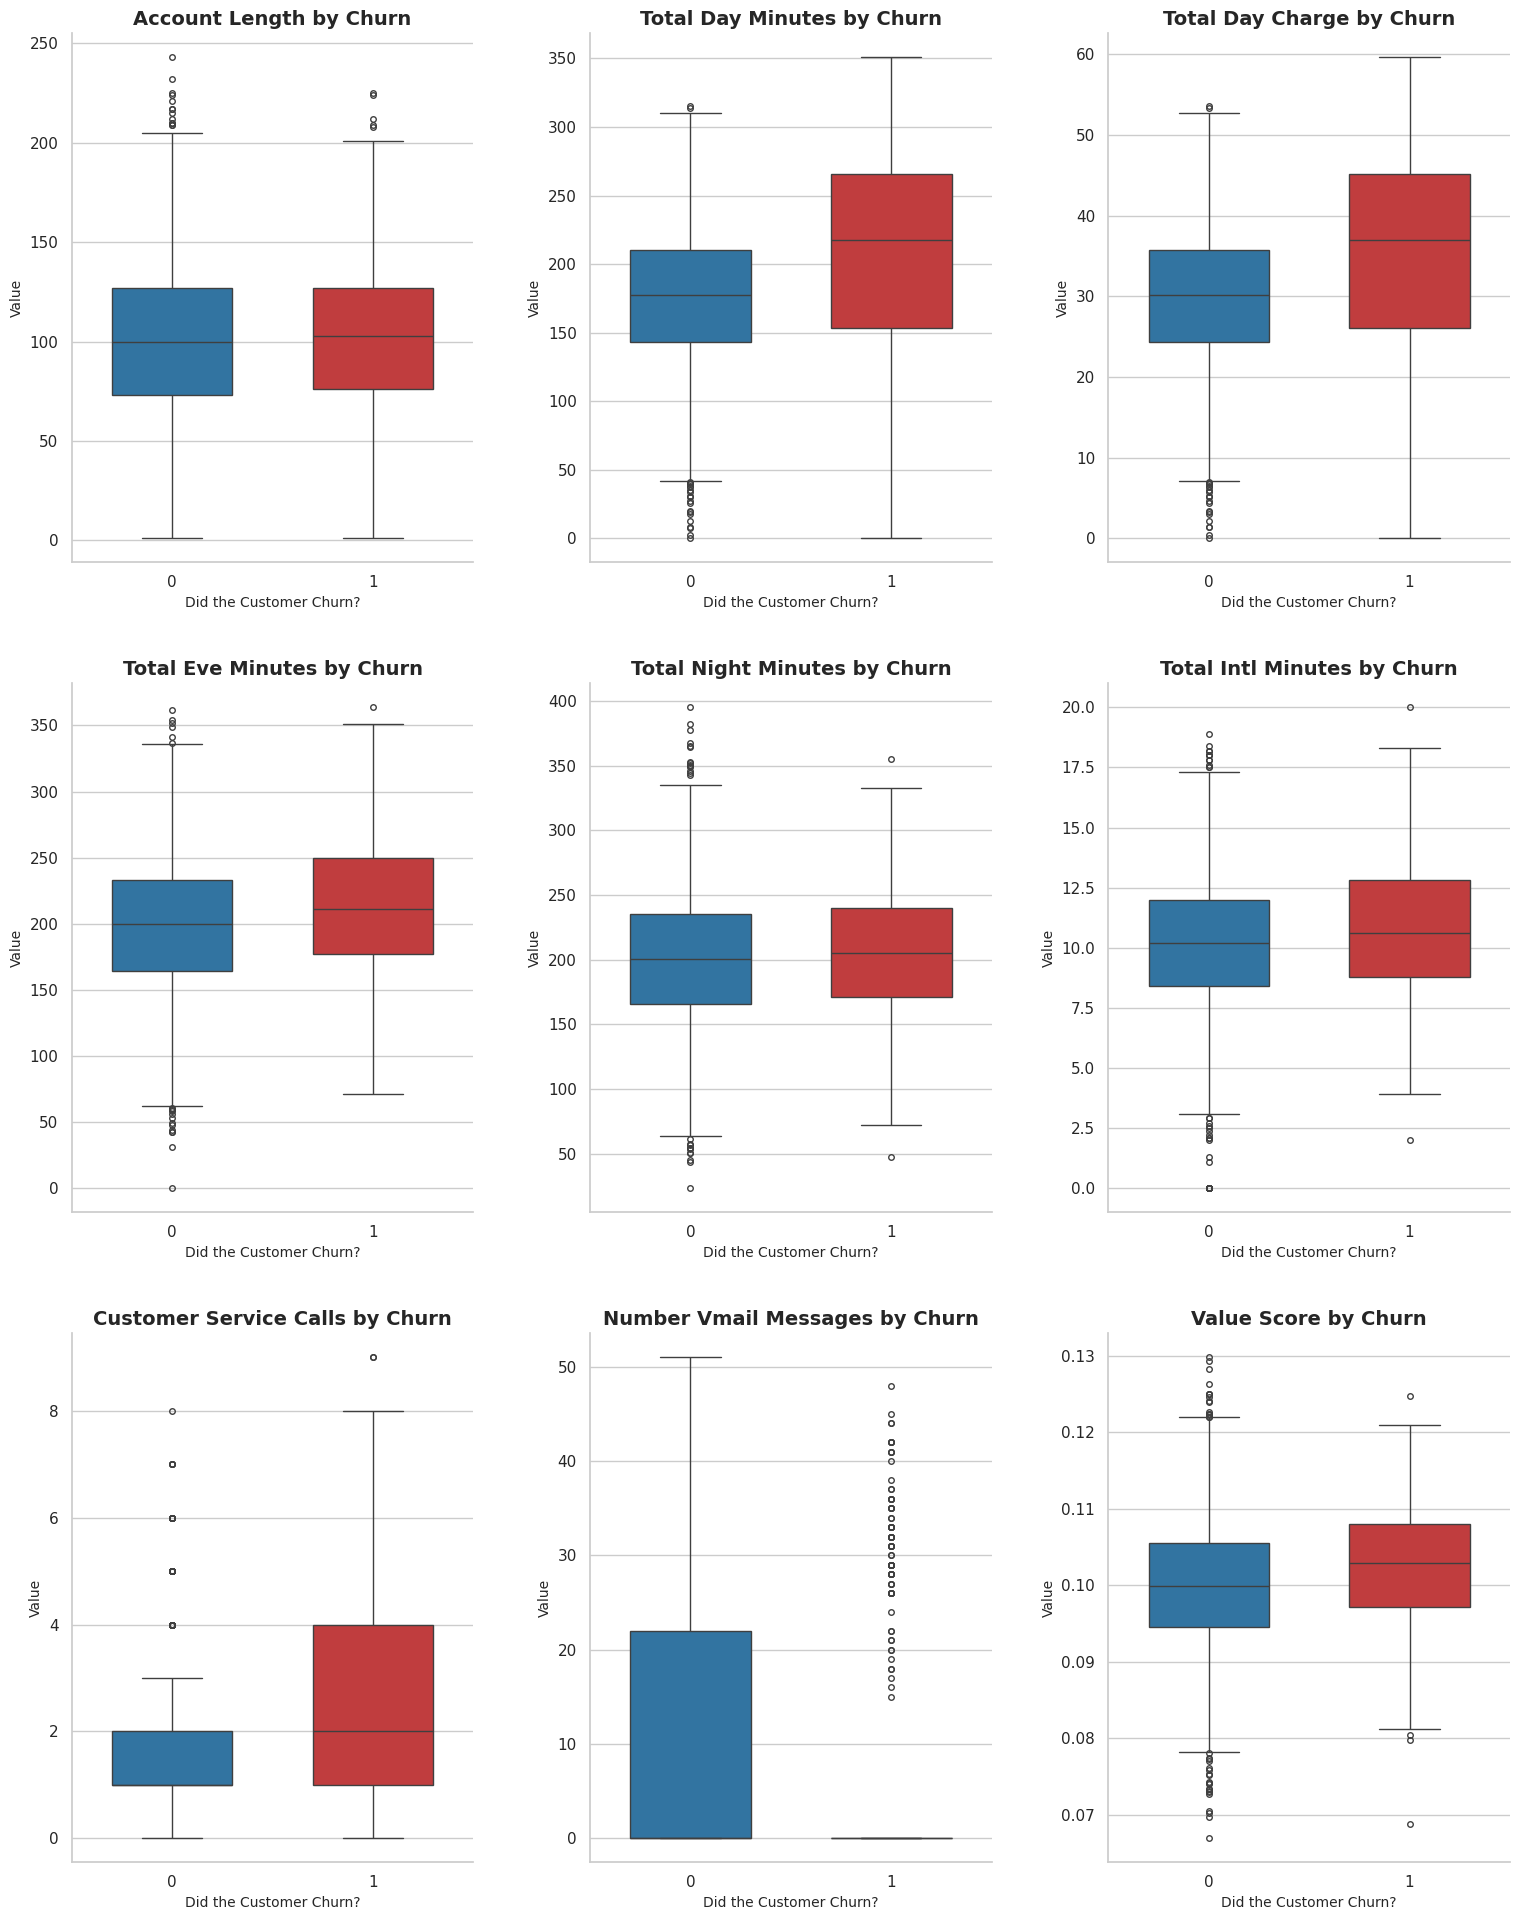

In [42]:
plot_boxplots(df, num_features)


# 9. Phase 8 - Scatter Plots

Scatter plots reveal the relationship between two features simultaneously, coloured by churn status. This is where we can see if churners cluster in a specific region of the feature space — something neither histograms nor box plots can show alone. We pair features that are conceptually related (e.g. minutes vs charge) and features we suspect interact (e.g. customer service calls vs day charge).


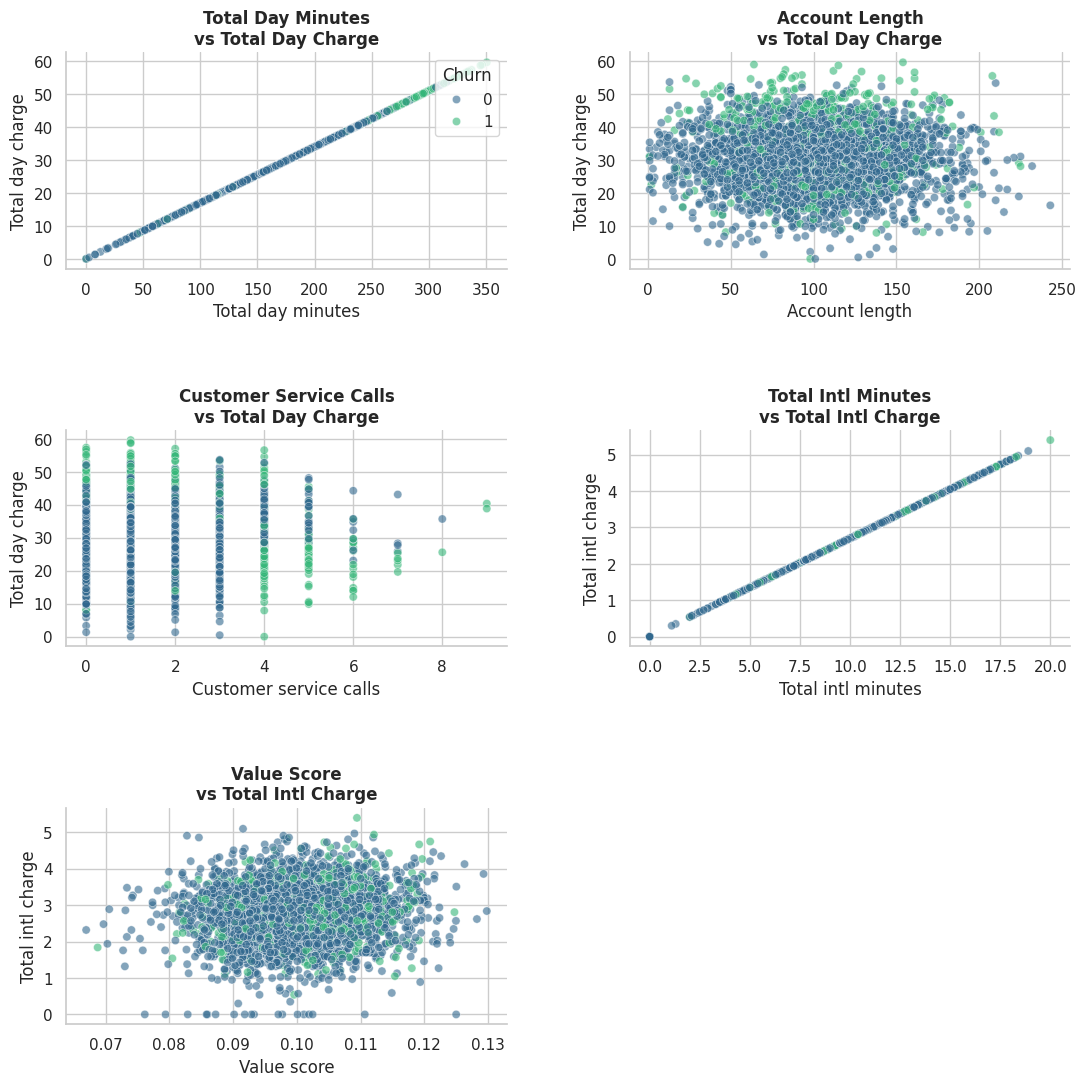

In [47]:
feature1 = ['Total day minutes', 'Account length', 'Customer service calls', 'Total intl minutes', 'value_score']
feature2 = ['Total day charge', 'Total day charge', 'Total day charge', 'Total intl charge', 'Total intl charge']
plot_scatterplots(df, feature1, feature2)

# 10. Phase 9 - Correlation Matrix

The correlation matrix quantifies what the visuals suggested. With 31 columns, a full heatmap would be unreadable, so we first rank all features by their absolute correlation with Churn, then build the matrix using only the top 10. This keeps the chart focused and informative. `mask=np.triu(...)` hides the upper triangle — it's a mirror of the lower, so removing it halves the visual noise.


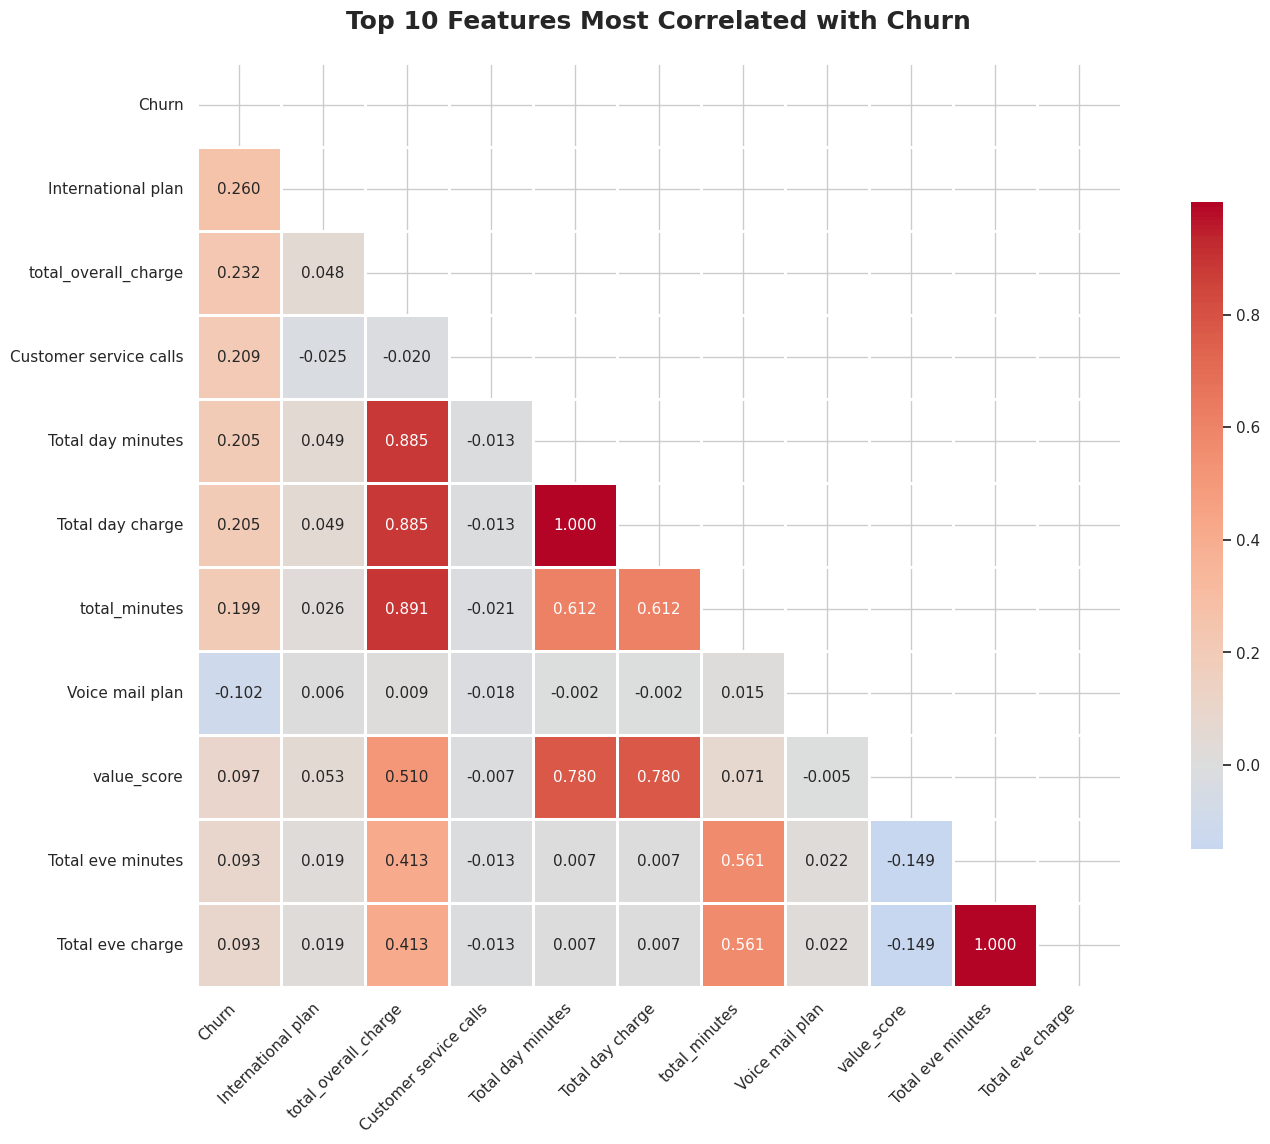

In [59]:
# The Mathematical Correlation (The Audition)
# We calculate correlation for all 31 columns first
full_corr = df.select_dtypes(include='number').corr()

# Pick the Top 10 (excluding churn's correlation with itself)
# We use .abs() to catch strong negative correlations too!
top_10_names = full_corr['Churn'].abs().sort_values(ascending=False).index[:11].tolist()

# Create the Focus Matrix
# This sub-matrix will only have 11 columns, with 'churn' at index 0
focus_corr = df[top_10_names].corr()

# The Correlation Heatmap
plt.figure(figsize=(18, 12)) # Large enough for 11 columns to be clear
mask = np.triu(np.ones_like(focus_corr, dtype=bool))

sns.heatmap(
    focus_corr,
    mask=mask,
    annot=True,
    fmt='.3f',              # Keeping your 3-decimal precision
    annot_kws={"size": 11}, # Perfectly sized for 11 columns
    cmap='coolwarm',
    center=0,
    linewidths=1,
    square=True,
    cbar_kws={"shrink": .7}
)

plt.title('Top 10 Features Most Correlated with Churn', fontsize=18, weight='bold', pad=25)
plt.xticks(rotation=45, ha='right')
plt.show()

## Phase 10 — Key Insights & Findings

### What the data tells us about customer churn

**Baseline:** 14.49% of customers in this dataset churned (483 out of 3,333). Every finding below should be read against that baseline.

---

**1. International Plan is the single strongest predictor of churn.**

Customers *with* an international plan churn at **42.4%** — nearly four times the baseline rate. Customers *without* one churn at 11.5%. This was the most surprising finding — it was not expected to outrank total day charge in the correlation matrix. A possible explanation: international plan customers are more likely to be high-spend, price-conscious users who comparison-shop more aggressively.

---

**2. Total day charge is a decisive churn factor.**

The box plots show clear separation — churners have consistently higher day charges than non-churners. The scatter plot confirms this further: customers with high day charges churn regardless of whether they have complaints. Even satisfied customers (low customer service calls) leave when the bill is high enough. This suggests pricing, not service quality alone, is the primary churn driver.

---

**3. Customer service calls ≥ 4 is a high-risk threshold.**

The `service_sentiment` cross-tabulation shows High_Risk customers (4+ service calls) churn at **51.7%** — more than half. Normal customers churn at 11.4%. Every additional complaint call past 3 appears to push a customer significantly closer to leaving.

---

**4. Evening and night minutes do not meaningfully separate churners from non-churners.**

The histograms and box plots for total evening minutes and total night minutes show near-identical distributions between Churn=0 and Churn=1. These features carry little predictive signal on their own.

---

**5. Voicemail plan is a mild churn protector.**

Customers *with* a voicemail plan churn at 8.7%, vs 16.7% for those without. It is not a dominant predictor, but the direction is clear — voicemail plan customers are more engaged with the service.

---

**6. Multicollinearity — what to drop before modelling.**

The correlation matrix reveals several near-perfect relationships:
- `Total day minutes` and `Total day charge`: correlation ≈ 1.0 — drop one
- `Total eve minutes` and `Total eve charge`: correlation = 1.0 exactly — drop one
- `Total day charge` and `total_overall_charge`: highly correlated — drop one

These pairs carry identical information. Using both in a model adds noise, not signal, and inflates variance in coefficient estimates.

---

**7. Recommendation — what a telecom company should act on first.**

Address pricing for high-usage customers before they reach the decision point. The data shows that customers with high day charges churn even when they have no service complaints — meaning retention is lost on pricing alone, not service failure. A targeted retention offer triggered when a customer's rolling day charge exceeds a threshold would be the highest-impact intervention this dataset supports.

---
*Codveda Data Science Internship — Level 1, Task 2 | Deborah Olofin*
